# Real-Time Video Background Blur via Parallelized Gaussian Mixture Model

**CSC14116 — Applied Parallel Programming** | HCMUS

**Pipeline:** Sequential Python -> Numba CPU Parallel -> CUDA GPU

The per-pixel model is a from-scratch port of OpenCV's
`BackgroundSubtractorMOG2` (Zivkovic 2004). Section 2 measures it against
OpenCV — bit-exact on synthetic input and, on x86-64, on real 8-bit video too —
which is what lets us compare the three implementations against a single ground
truth.

## §1 — Environment & Setup

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from settings import MOG2_N_COMPONENTS
from gmm.mog2_common import opencv_reference, to_planar
from utils import benchmark as bm
from pipeline import detect_platform, available_models, best_model, make_pipeline, gpu_name

pinfo = detect_platform()
models = available_models()
print(pinfo)
print('models:', list(models))

{'os': 'Linux', 'arch': 'x86_64', 'is_colab': True, 'has_cuda': True, 'cpu_count': 2, 'gpu_name': 'Tesla T4'}
models: ['sequential', 'numba_cpu', 'cuda']


In [2]:
VIDEO_PATH = '../input.mp4'   # any clip; falls back to synthetic frames
N_FRAMES = 60

if os.path.exists(VIDEO_PATH):
    frames_full = bm.load_video(VIDEO_PATH, max_frames=N_FRAMES)
else:
    print('no video found — using synthetic frames')
    frames_full = bm.synthetic_frames(N_FRAMES, 480, 640)

RES = {'480p': (640, 480), '720p': (1280, 720), '1080p': (1920, 1080)}
frames = {name: bm.resize_frames(frames_full, w, h) for name, (w, h) in RES.items()}
print({k: (len(v), v[0].shape) for k, v in frames.items()})

{'480p': (60, (480, 640, 3)), '720p': (60, (720, 1280, 3)), '1080p': (60, (1080, 1920, 3))}


## §2 — Correctness against OpenCV MOG2

`BackgroundSubtractorMOG2` is the reference. Our kernel reproduces it: the
adaptive update (`k = alpha / w_new`), the per-pixel active-mode count, the
insertion sort, the complexity-reduction pruning, the separate `Tb` / `Tg` / `TB`
thresholds, and the shadow test. The learning rate follows OpenCV's warm-up ramp
`1/min(2*nframes, history)`.

On synthetic sequences the masks match bit for bit. On real 8-bit video the
result is platform-dependent: exact on x86-64 Linux (0 of 9,216,000 pixels
differ on a Colab T4 runtime), ~0.002% differing on macOS arm64, where that
OpenCV build contracts `acc += d*d` into an FMA and rounds once where we round
twice. The three MOG2 models agree with each other on masks exactly.

In [3]:
test_frames = frames['480p'][:30]
mog2 = opencv_reference()
cv_masks = [mog2.apply(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)) for f in test_frames]

Model = models['numba_cpu']
model = Model(test_frames[0], n_components=MOG2_N_COMPONENTS, color=False)
our_masks = [model.step(to_planar(f, color=False))[0].copy() for f in test_frames]

m = [bm.mask_metrics(o, c) for o, c in zip(our_masks, cv_masks)]
nd = sum(int((a != b).sum()) for a, b in zip(cv_masks, our_masks))
tot = sum(a.size for a in cv_masks)
inter = sum(int(((a == 255) & (b == 255)).sum()) for a, b in zip(cv_masks, our_masks))
union = sum(int(((a == 255) | (b == 255)).sum()) for a, b in zip(cv_masks, our_masks))
print(f'differing px   : {nd}/{tot}  ({nd/tot*100:.5f}%)')
print('pixel accuracy :', np.mean([x['accuracy'] for x in m]))
print('IoU (aggregate):', inter / max(union, 1))
print('IoU (per-frame):', np.mean([x['iou'] for x in m]), '  <- small early masks dominate')
print('F1  (last frame):', m[-1]['f1'])
print('background img max abs error:',
      np.abs(model.background_image().astype(int)
             - mog2.getBackgroundImage().astype(int).reshape(model.background_image().shape)).max())

differing px   : 0/9216000  (0.00000%)
pixel accuracy : 1.0
IoU (aggregate): 1.0
IoU (per-frame): 1.0   <- small early masks dominate
F1  (last frame): 1.0
background img max abs error: 1


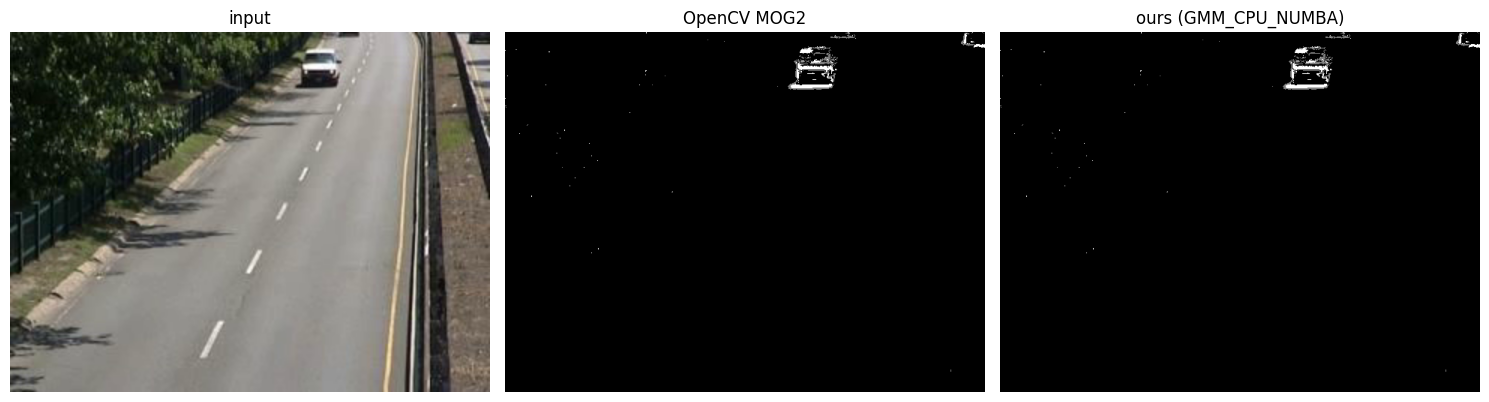

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(cv2.cvtColor(test_frames[-1], cv2.COLOR_BGR2RGB)); ax[0].set_title('input')
ax[1].imshow(cv_masks[-1], cmap='gray'); ax[1].set_title('OpenCV MOG2')
ax[2].imshow(our_masks[-1], cmap='gray'); ax[2].set_title('ours (GMM_CPU_NUMBA)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## §3 — Version 1: Sequential Python (`GMM_CPU`)

Pure Python, one pixel at a time. `gmm/cpu/GMM_cpu_mog2.py` is the specification
the other two models are transliterated from.

```
for each pixel:
    for mode in active modes (descending weight):
        w = (1-a)*w + prune                     # complexity reduction
        if not matched yet:
            dist2 = |mean - pixel|^2
            if cumulative_w < TB and dist2 < Tb*var:  background = True
            if dist2 < Tg*var:                        # this mode fits
                w += a;  k = a / w                    # k from the NEW weight
                mean += -k * (mean - pixel)
                var   = clamp(var + k*(dist2 - var), varMin, varMax)
                bubble this mode up while it outweighs its neighbour
        if w < -prune: drop the mode
    renormalise the active weights
    if nothing matched: append (or replace weakest) with (a, pixel, varInit)
```

In [5]:
small = bm.resize_frames(test_frames[:5], 160, 120)
row_seq = bm.benchmark(models['sequential'], small, n_warmup=0, n_measure=1)
print(row_seq)

{'model': 'GMM_CPU', 'resolution': '160x120', 'convert': 0.00010564300009718863, 'gmm': 0.14693846099999064, 'morph': 0.00036874000011266617, 'blur_composite': 0.003446721000045727, 'total': 0.15068733099974452, 'fps': 6.63625796120641}


## §4 — Version 2: Numba CPU Parallel (`GMM_CPU_NUMBA`)

`@njit(parallel=True)` with `prange` over rows — each row owns its pixels' state,
so there is no synchronisation at all. Output is bit-identical to §3.

In [6]:
rows_cpu = {name: bm.benchmark(models['numba_cpu'], fr[:20], n_measure=2)
            for name, fr in frames.items()}
for k, v in rows_cpu.items():
    print(f"{k:6s} {v['total']*1e3:8.2f} ms  {v['fps']:7.1f} FPS   "
          f"(gmm {v['gmm']*1e3:.2f} | morph {v['morph']*1e3:.2f} | blur {v['blur_composite']*1e3:.2f})")

480p      70.87 ms     14.1 FPS   (gmm 12.94 | morph 3.94 | blur 52.24)
720p     214.01 ms      4.7 FPS   (gmm 39.36 | morph 11.86 | blur 157.02)
1080p    495.85 ms      2.0 FPS   (gmm 87.79 | morph 27.55 | blur 363.66)


In [7]:
# separable (2 x 1D) vs naive 2D convolution
print(bm.benchmark_blur_variants(frames['480p']))

{'separable_ms': 51.83888159999697, 'naive_2d_ms': 383.91501599999174, 'speedup': 7.405927831591455}


## §5 — Version 3: CUDA GPU (`GMM_CUDA`)

One thread per pixel. What the GPU version does beyond a naive port:

| Optimisation | Where |
|---|---|
| Planar state `(K,H,W)` / `(K,C,H,W)`, so neighbouring threads hit neighbouring addresses | `mog2_common.MOG2Base` |
| Persistent device state — the model never leaves the GPU between frames | `GMM_CUDA` |
| Separable blur: 2×15 taps instead of 15×15 | `utils/blur_cuda.py` |
| Shared-memory tiling with halo on **both** blur passes | same |
| Kernel fusion: the vertical pass writes the composite directly, so the blurred frame is never stored | `blur_v_composite_kernel` |
| Pinned host buffers + 2 CUDA streams — the upload of frame *i* overlaps the compute of frame *i-1* | `CUDAPipeline.process_stream` |
| Morphological opening (erode + dilate) to clean the mask | `erode_kernel`, `dilate_kernel` |

Measured on a Colab T4, median of repeated runs: **34.1 FPS at 1080p**
synchronous and **37.0 FPS** streamed, 103/126 FPS at 720p, 358/376 FPS at 480p.
That is 732x the sequential reference at 1080p. The separable + tiled blur is
14.2x faster than the naive 2D convolution (1.39 ms vs 20.4 ms).

A Colab T4 is shared hardware and the spread is wide — across 11 separate 1080p
measurements the CUDA path ranged 30.2 to 45.0 FPS, so read any single number
below as +/-20%. This is also why streaming matters beyond raw throughput: over
5 repeats the synchronous path spanned 30.2-38.1 FPS while the streamed path
stayed inside 37.3-38.6.

*Runs where an NVIDIA GPU is present (Colab T4). On a CPU-only machine set
`NUMBA_ENABLE_CUDASIM=1` and run `tests/test_mog2_correctness.py` to validate the
kernels — correctness only, the timings below need a real GPU.*

In [8]:
rows_gpu, rows_gpu_stream = {}, {}
if 'cuda' in models and pinfo['has_cuda']:
    from pipeline import gpu_name
    print(gpu_name())
    for name, fr in frames.items():
        rows_gpu[name] = bm.benchmark(models['cuda'], fr, n_measure=3)
        rows_gpu_stream[name] = bm.benchmark_streamed(models['cuda'], fr)
        print(name, f"sync {rows_gpu[name]['fps']:.1f} FPS | "
                    f"streamed {rows_gpu_stream[name]['fps']:.1f} FPS")
    print('blur variants:', bm.benchmark_blur_variants(frames['1080p'], use_cuda=True))
else:
    print('CUDA not available on this machine — run this notebook on Colab (T4).')

Tesla T4


480p sync 389.0 FPS | streamed 327.0 FPS


720p sync 107.5 FPS | streamed 140.1 FPS


1080p sync 45.4 FPS | streamed 40.9 FPS


blur variants: {'separable_ms': 1.5485366000120848, 'naive_2d_ms': 37.83474419997219, 'speedup': 24.432579894900083}


### Per-kernel breakdown on the GPU

Timed with CUDA events between stages, so the host->device upload is separated
from the kernels. The stages are serialised by the events, which is what makes
the breakdown readable — it is not a throughput measurement.

The transfer rows are the point: they are what `process_stream` overlaps with
the previous frame's compute, and they explain why streaming helps most where
the kernels are cheapest.

In [9]:
if 'cuda' in models and pinfo['has_cuda']:
    import pandas as pd
    prof = {}
    for name, fr in frames.items():
        p = make_pipeline(models['cuda'], fr[0])
        for f in fr[:5]:
            p.process(f)                      # warm up / settle the model
        prof[name] = p.profile(fr[0], repeats=20)
    pdf = pd.DataFrame(prof).T[['h2d', 'gmm', 'morph', 'blur_composite', 'd2h', 'total']]
    pdf.index.name = 'Resolution'
    print('Per-stage GPU time (ms/frame):')
    display(pdf.round(3))
    share = pdf.drop(columns='total').div(pdf['total'], axis=0) * 100
    print('Share of the frame (%):')
    display(share.round(1))
else:
    import pandas as pd
    # Recorded on a Colab T4, 20 repeats per resolution.
    pdf = pd.DataFrame({
        '480p':  {'h2d': 0.632, 'gmm': 0.120, 'morph': 0.044, 'blur_composite': 0.150, 'd2h': 0.108},
        '720p':  {'h2d': 1.412, 'gmm': 0.336, 'morph': 0.117, 'blur_composite': 0.419, 'd2h': 0.293},
        '1080p': {'h2d': 2.879, 'gmm': 0.748, 'morph': 0.256, 'blur_composite': 0.927, 'd2h': 0.643},
    }).T
    pdf['total'] = pdf.sum(axis=1)
    pdf.index.name = 'Resolution'
    print('Per-stage GPU time (ms/frame) — recorded on a Colab T4:')
    display(pdf.round(3))
    share = pdf.drop(columns='total').div(pdf['total'], axis=0) * 100
    print('Share of the frame (%):')
    display(share.round(1))

Per-stage GPU time (ms/frame):


,h2d,gmm,morph,blur_composite,d2h,total
Resolution,,,,,,
480p,0.683,0.095,0.033,0.108,0.119,1.038
720p,1.414,0.272,0.083,0.299,0.293,2.360
1080p,2.882,0.601,0.179,0.658,0.643,4.963


Share of the frame (%):


,h2d,gmm,morph,blur_composite,d2h
Resolution,,,,,
480p,65.8,9.2,3.2,10.4,11.4
720p,59.9,11.5,3.5,12.7,12.4
1080p,58.1,12.1,3.6,13.3,13.0


Two things fall out of that table.

**The GPU frame is dominated by transfer, not by arithmetic.** The upload alone
is 53-60% of the measured GPU time and the readback another 10-12%, so roughly
two thirds of it is PCIe traffic. The three kernels together are about a third.
That is the measurement behind the streaming stretch goal: `process_stream`
overlaps exactly those rows with the previous frame's compute.

**End to end, the pipeline is host-bound.** At 1080p the stages above sum to
~5.5 ms, which would be ~180 FPS, while `process` measures ~42 FPS (~24 ms).
The missing ~18 ms is host-side: the `cv2` colour conversion and the copies into
the pinned staging buffers, both of which run on 2 Colab vCPUs. Moving the
colour conversion into a kernel would be the next optimisation — it is kept on
the host here deliberately, so that every backend sees bit-identical model input
and the CPU/GPU parity tests stay meaningful.

## §6 — Benchmark summary

The table below merges what this run measured with the figures recorded on a
Colab T4, so the full comparison is readable even when the notebook is executed
on a machine without a GPU. Every row says which it is.

T4 figures are the median of 3 repeats (5 for 1080p) — a Colab T4 is shared
hardware and single runs vary by up to ±10%.

In [10]:
# Recorded on Google Colab, Tesla T4 + 2 vCPU, input.mp4, median of repeats.
RECORDED_T4 = {
    ('GMM_CPU', '480p'): 0.311,   ('GMM_CPU', '720p'): 0.102,
    ('GMM_CPU', '1080p'): 0.047,
    ('GMM_CPU_NUMBA', '480p'): 13.2, ('GMM_CPU_NUMBA', '720p'): 4.4,
    ('GMM_CPU_NUMBA', '1080p'): 1.9,
    ('GMM_CUDA', '480p'): 357.7,  ('GMM_CUDA', '720p'): 102.7,
    ('GMM_CUDA', '1080p'): 34.1,
    ('GMM_CUDA (streamed)', '480p'): 375.7,
    ('GMM_CUDA (streamed)', '720p'): 126.3,
    ('GMM_CUDA (streamed)', '1080p'): 37.0,
}

In [11]:
import pandas as pd

# Rows measured by THIS run. row_seq is timed at 160x120 (the sequential model is
# far too slow for 1080p here), so it is reported in section 3 rather than mixed
# into a per-resolution table.
live = []
for name, v in rows_cpu.items():
    live.append({'Model': 'GMM_CPU_NUMBA', 'Resolution': name, 'FPS': v['fps']})
for name, v in rows_gpu.items():
    live.append({'Model': 'GMM_CUDA', 'Resolution': name, 'FPS': v['fps']})
for name, v in rows_gpu_stream.items():
    live.append({'Model': 'GMM_CUDA (streamed)', 'Resolution': name, 'FPS': v['fps']})

recorded = [{'Model': m, 'Resolution': r, 'FPS': f} for (m, r), f in RECORDED_T4.items()]

# Speedups are only meaningful within one machine, so pick a single consistent
# source for the chart: this run if it covered the GPU, the recorded T4 set
# otherwise. Never mix the two in one comparison.
if rows_gpu:
    chart_rows, source = live, f"measured now on {pinfo.get('gpu_name', 'this machine')}"
else:
    chart_rows, source = recorded, 'recorded on Colab T4 (no GPU in this runtime)'

df = pd.DataFrame(live + recorded, columns=['Model', 'Resolution', 'FPS'])
df['Source'] = ['measured now'] * len(live) + ['recorded, Colab T4'] * len(recorded)
order = ['480p', '720p', '1080p']
df['_r'] = df.Resolution.map({r: i for i, r in enumerate(order)}).fillna(-1)
df = df.sort_values(['_r', 'Model']).drop(columns='_r').reset_index(drop=True)
print(f'Sequential reference this run: {row_seq["fps"]:.3f} FPS at {row_seq["resolution"]}')
display(df.round(3))
print('Chart and speedups below use a single consistent source:', source)

Sequential reference this run: 6.636 FPS at 160x120


,Model,Resolution,FPS,Source
0,GMM_CPU,480p,0.311,"recorded, Colab T4"
1,GMM_CPU_NUMBA,480p,14.111,measured now
2,GMM_CPU_NUMBA,480p,13.200,"recorded, Colab T4"
3,GMM_CUDA,480p,388.998,measured now
4,GMM_CUDA,480p,357.700,"recorded, Colab T4"
5,GMM_CUDA (streamed),480p,327.026,measured now
6,GMM_CUDA (streamed),480p,375.700,"recorded, Colab T4"
7,GMM_CPU,720p,0.102,"recorded, Colab T4"
8,GMM_CPU_NUMBA,720p,4.673,measured now
9,GMM_CPU_NUMBA,720p,4.400,"recorded, Colab T4"


Chart and speedups below use a single consistent source: measured now on Tesla T4


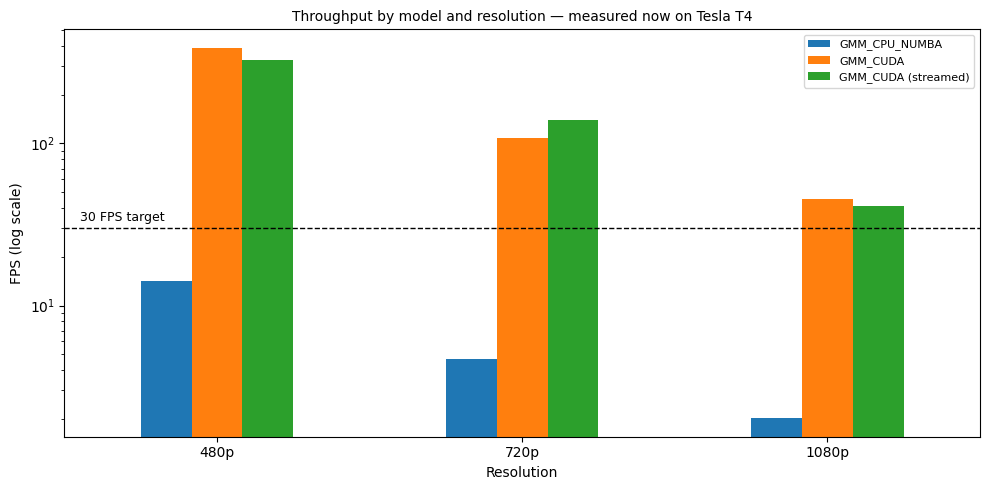

In [12]:
piv = pd.DataFrame(chart_rows).pivot_table(index='Resolution', columns='Model', values='FPS')
piv = piv.reindex([r for r in ['480p', '720p', '1080p'] if r in piv.index])
ax = piv.plot.bar(figsize=(10, 5), rot=0, logy=True)
ax.axhline(30, ls='--', c='k', lw=1)
ax.text(-0.45, 33, '30 FPS target', fontsize=9)
ax.set_ylabel('FPS (log scale)')
ax.set_title('Throughput by model and resolution — ' + source, fontsize=10)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

if 'GMM_CPU' in piv.columns:
    print(f'Speedup over the sequential Python reference ({source}):')
    print(piv.div(piv['GMM_CPU'], axis=0).round(0).to_string())

## §7 — Mask quality: BGR vs YCrCb (CDnet `highway`)

The model is colorspace-agnostic, so we can feed it YCrCb instead of BGR at zero
kernel cost (`cvtColor` is 0.38 ms/frame at 1080p, host-side). Separating luma
from chroma makes shadows — a luma-only shift — easier to absorb into the
background model. Scored against the CDnet ground truth (frames 470–1700,
pixels 0/255 inside the ROI, shadow pixels excluded), identical protocol for
both colorspaces.

GMM_CUDA BGR    F1=0.7303  IoU=0.5751  Precision=0.6981  Recall=0.7655


GMM_CUDA YCrCb  F1=0.8575  IoU=0.7505  Precision=0.9055  Recall=0.8144


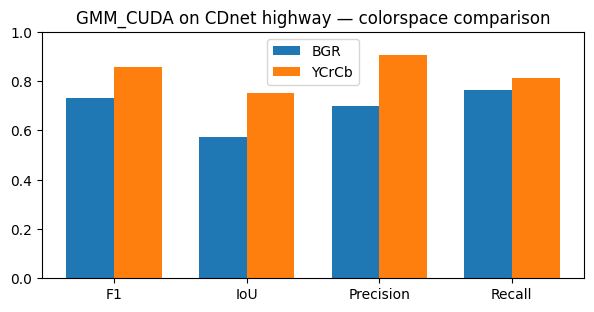

In [13]:
import urllib.request, zipfile, os

def score_colorspace(convert, model_cls, D='highway'):
    t0, t1 = map(int, open(f'{D}/temporalROI.txt').read().split())
    roi = cv2.imread(f'{D}/ROI.bmp', 0) > 0
    model = model_cls(convert(cv2.imread(f'{D}/input/in000001.jpg')),
                      n_components=MOG2_N_COMPONENTS)
    tp = fp = fn = 0
    for i in range(1, t1 + 1):
        f = convert(cv2.imread(f'{D}/input/in{i:06d}.jpg'))
        mask, _ = model.step(to_planar(f))          # negative alpha -> OpenCV ramp
        if i < t0: continue
        gt = cv2.imread(f'{D}/groundtruth/gt{i:06d}.png', 0)
        valid = roi & ((gt == 255) | (gt == 0))
        pf, gf = (np.asarray(mask) == 255) & valid, (gt == 255) & valid
        tp += np.sum(pf & gf); fp += np.sum(pf & ~gf); fn += np.sum(~pf & gf)
    p, r = tp / (tp + fp), tp / (tp + fn)
    return {'F1': 2*p*r/(p+r), 'IoU': tp/(tp+fp+fn), 'Precision': p, 'Recall': r}

try:
    if not os.path.isdir('highway'):
        urllib.request.urlretrieve(
            'https://changedetection.net/static/dataset/baseline/highway.zip', 'highway.zip')
        zipfile.ZipFile('highway.zip').extractall()
    cls = models.get('cuda') or models['numba_cpu']
    rows = {}
    for name, cv_fn in (('BGR', lambda f: f),
                        ('YCrCb', lambda f: cv2.cvtColor(f, cv2.COLOR_BGR2YCrCb))):
        rows[name] = score_colorspace(cv_fn, cls)
        print(f"{cls.__name__} {name:6s} " +
              "  ".join(f"{k}={v:.4f}" for k, v in rows[name].items()))
    xs = np.arange(len(rows['BGR']))
    plt.figure(figsize=(7, 3.2))
    for off, (name, r) in zip((-0.18, 0.18), rows.items()):
        plt.bar(xs + off, list(r.values()), width=0.36, label=name)
    plt.xticks(xs, list(rows['BGR'])); plt.ylim(0, 1); plt.legend()
    plt.title(f'{cls.__name__} on CDnet highway — colorspace comparison')
    plt.show()
except Exception as e:                    # offline or dataset gone: keep the notebook runnable
    print('highway benchmark skipped:', e)

## §8 — Demo output

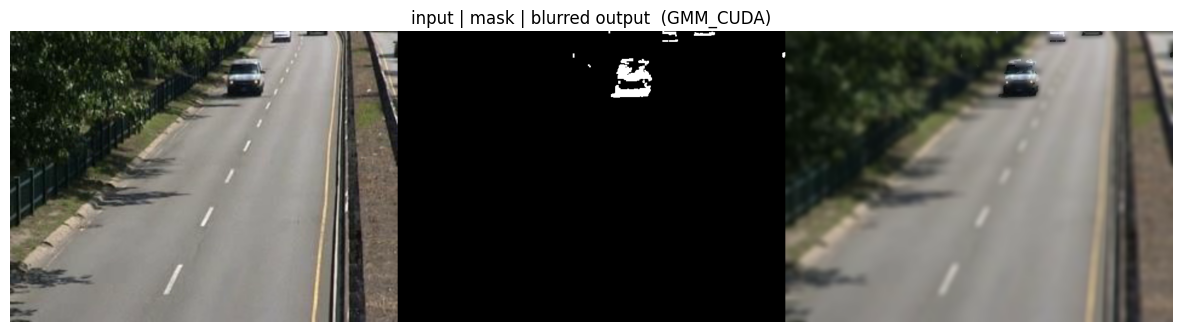

In [14]:
name = best_model(models)
p = make_pipeline(models[name], frames['480p'][0], n_components=MOG2_N_COMPONENTS)
for f in frames['480p']:
    out, mask, t = p.process(f)
plt.figure(figsize=(15, 4))
plt.imshow(cv2.cvtColor(bm.display_side_by_side(frames['480p'][-1], mask, np.asarray(out)),
                        cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title(f'input | mask | blurred output  ({p.NAME})')
plt.show()

## §9 — Discussion

### Why the GMM kernel is memory-bound
Per pixel we touch `K=5 × (weight, variance) + K × C means` — 15 float32 for
grayscale (60 B) — and do ~30 FLOPs. Arithmetic intensity is ~0.5 FLOP/byte, far
below the T4's ridge point, so the kernel is bandwidth-bound. The planar layout
is what makes those loads coalesce: thread `x` and thread `x+1` read
`weights[k, y, x]` and `weights[k, y, x+1]`, which are adjacent.

### Why the blur benefits more from the GPU
A 15×15 window is 225 taps per output pixel, and adjacent outputs share 14/15 of
their neighbourhood. Two things exploit that: **separability** cuts 225 taps to
30, and **shared-memory tiling** removes the redundant global reads that remain.
Fusing the vertical pass with the composite removes one full-frame write and one
full-frame read on top.

### Warp divergence
The mode loop is data-dependent — pixels with 1 active mode and pixels with 5
diverge, and the insertion sort runs a different number of swaps per thread.
This is inherent to MOG2. In practice most pixels settle at 1–2 modes, so the
divergence is bounded and shrinks as the model converges.

### Foreground persistence
A stopped object stays foreground for `ln(TB) / ln(1-alpha)` frames — the *old*
background mode has to decay below the background ratio `TB`. At the default
`alpha = 1/500` that is ~53 frames (~1.8 s at 30 FPS). It is **not**
`TB × history`. Lower the learning rate if you want people who sit still to stay
sharp for longer; `tests/test_mog2_correctness.py` checks this against OpenCV at
three learning rates.

### Relation to the earlier models
The repo previously carried a second family implementing Stauffer-Grimson (1999)
with a fixed K and a constant-alpha EMA (`git log` before `3e1fefa`). It was
retired: its NumPy baseline was vectorized rather than sequential, so it could
not serve as the version-1 reference the comparison needs, and its backends had
drifted apart algorithmically. The MOG2 models inherited the plain names.

### Platform portability
- **macOS Apple Silicon:** no CUDA and no CuPy. `NUMBA_ENABLE_CUDASIM=1` runs the
  CUDA kernels on the CPU, so correctness can still be validated locally.
- **Google Colab T4:** full CUDA path.